# Graph ML for Chemoinformatics

The purpose of this practical work is to handle several datasets and strategies based on graphs in order to derive a predictive model. The considered datasets are :
 * MUTAG : 188 molecules associated to a property of being mutagen or not. It thus corresponds to a classification problem.
 * Acyclic : 183 molecules associated with their boiling points. It thus corresponds to a regression problem.
 * COBRA dataset : 111 molecules with electrophilicity. This dataset has been used in a scientific paper authored in collaboration with COBRA and LITIS.

To derive our predictive models, we will use models based on GED, embeddings, kernels and GNNs.

## Datasets

First, we will load the datasets we will use. 

In [4]:
%load_ext autoreload
%autoreload 2


In [5]:
%matplotlib inline 

# pour afficher les graphiques dans le notebook

# Utility libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt


### Loading MUTAG

Introduced by Debnath et al. in Structure-activity relationship of mutagenic aromatic and heteroaromatic nitro compounds

In particular, MUTAG is a collection of nitroaromatic compounds and the goal is to predict their mutagenicity on Salmonella typhimurium. Input graphs are used to represent chemical compounds, where vertices stand for atoms and are labeled by the atom type (represented by one-hot encoding), while edges between vertices represent bonds between the corresponding atoms. It includes 188 samples of chemical compounds with 7 discrete node labels.

[MUTAG](https://paperswithcode.com/dataset/mutag)

In [6]:
#  for MUTAG
# Run this cell if you env is correctly set up.
from datasets.tu_dataset import MutagDataset
mutag = MutagDataset() 
graphs_MUTAG = mutag.graphs
y_MUTAG = mutag.targets


/home/bgauzere/.cache/pypoetry/virtualenvs/ia-pour-la-chimie-2XarQKld-py3.8/lib/python3.8/site-packages/torch_geometric/data/in_memory_dataset.py:284: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


In [5]:
import pickle

with open('data/data_mutag.pkl', 'wb') as f:
    pickle.dump((graphs_MUTAG, y_MUTAG), f)


In [6]:
import pickle

with open('data/data_mutag.pkl', 'rb') as f:
    graphs_MUTAG, y_MUTAG = pickle.load(f)

NodeDataView({0: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 1: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 2: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 3: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 4: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 5: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 6: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 7: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 8: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 9: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 10: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 11: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 12: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 13: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}, 14: {'x': [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'N'}, 15: {'x': [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'O'}, 16: {'x': [0.0, 0.0,

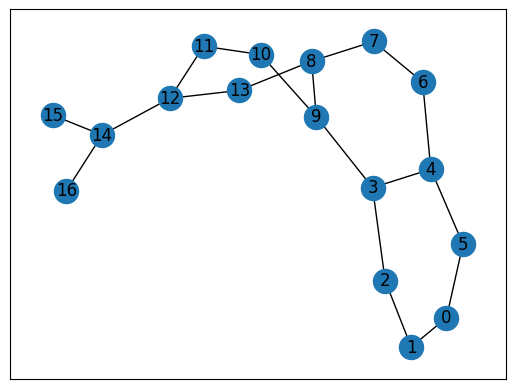

In [7]:
import numpy as np
np.unique(y_MUTAG,return_counts=True)

nx.draw_networkx(graphs_MUTAG[0])
graphs_MUTAG[0].nodes(data=True)

### Loading Acyclic

This dataset is originally composed of 185 acyclic molecules (Cherqaoui et al., 1994a) but has been reduced to 183 after identifying two duplicates. This problem consists in predicting boiling point of molecules. These molecules contain several hetero atoms and are thus represented as acyclic labeled graphs. 

>Cherqaoui, D., Villemin, D., Mesbah, A., Cense, J. M., Kvasnicka, V., 1994a. Use of a Neural Network to Determine the Normal Boiling Points of Acyclic Ethers, Peroxides, Acetals and their Sulfur Analogues. J. Chem. Soc. Faraday Trans. 90, 2015–2019.

>Gaüzère, Benoit, Luc Brun, Didier Villemin. 2012. « Two new graphs kernels in chemoinformatics ». Pattern Recognition Letters 33 (15): 2038‑47. https://doi.org/10.1016/j.patrec.2012.03.020.


In [27]:

# Run this cell if you env is correctly set up.
from datasets.acyclic import AcyclicDataset
acyclic = AcyclicDataset() #load Acyclic dataset from gklearn

graphs_Acyclic = acyclic.graphs
y_Acyclic = acyclic.targets
X_Acyclic = acyclic.graph_data

In [29]:
import pickle

with open('data/data_acyclic.pkl', 'wb') as f:
    pickle.dump((graphs_Acyclic, y_Acyclic, X_Acyclic), f)

In [30]:
import pickle

with open('data/data_acyclic.pkl', 'rb') as f:
    graphs_Acyclic, y_Acyclic, X_Acyclic = pickle.load(f)

In [31]:
print(len(graphs_Acyclic), len(y_Acyclic), len(X_Acyclic))

183 183 183


# Graph Embedding

First, we will compute some descriptors for Acyclic so as to be able to run a SVM of this graph features. To do so, we will use the Morgan Fingerprint algorithm which extracts the number of occurences of some substructures, and store this data into a fixed size vector.

The matrix visualization will help you to check the embeddings of the graph. 

1) In this `X_acyclic` matrix, what does represent a line and a column ?
2) What do you think about this embedding ?

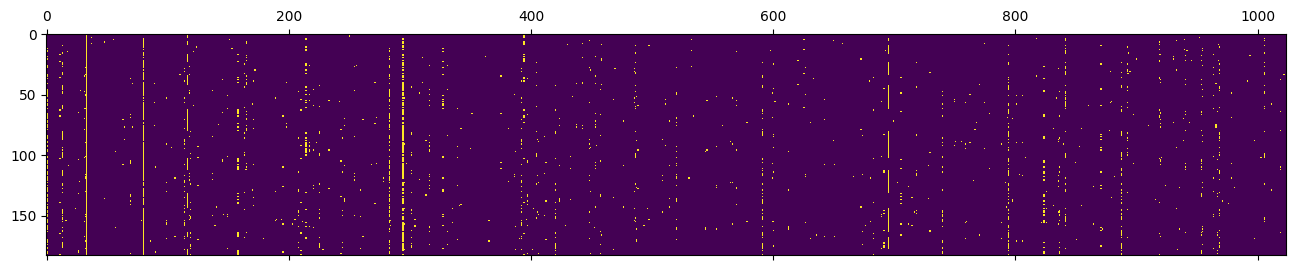

In [32]:

X_Acyclic = acyclic.graph_data

plt.matshow(X_Acyclic)
plt.show()



Now we will derive a predictive model which aim to output the boiling point of each molecule.

1) Complete the code to split the dataset between a train and a test set. Why this step is required ?
2) Complete the code to fit a SVM using the train set
3) Compute the mean absolute error of the prediction on both train and test set. Comment.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error


X_train, X_test, y_train, y_test = train_test_split(X_Acyclic, y_Acyclic,test_size=.1,random_state=42)

clf = SVR()
clf.fit(X_train,y_train)

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
mae_train = np.mean(np.abs(y_pred_train - y_train))
mae_test = np.mean(np.abs(y_pred_test - y_test))
print(mae_train)
print(mae_test)
plt.plot(y_train, y_pred_train,'o')
plt.plot(y_test, y_pred_test,'o')

# it doesn't work well...

NameError: name 'X_Acyclic' is not defined

SVR method comes with several hyperparameters which can be tuned so as to have a better regressor. We will identify some hyperparameters and tune them in a proper way.

1) What are the hyperparameters of SVR ? Check the documentation of the SVR method.
2) What protocol do you propose to tune them ?
3) Complete the code so as to fit the hyperparameters.
4) Compute your performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

# parameters = {'param_name':[param values]}
parameters = {'C' : [1,10,100,1000], 'epsilon':[.001, .01, .1, 1], 'gamma' : ['auto', 'scale', 1e-4, 1e-2, 1, 10]}

svr = SVR()
clf = GridSearchCV(svr, parameters,verbose=2)
clf.fit(X_train, y_train)

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
mae_train = np.mean(np.abs(y_pred_train - y_train))
mae_test = np.mean(np.abs(y_pred_test - y_test))
print(mae_train)
print(mae_test)

# Results are better


Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END .....................C=1, epsilon=0.001, gamma=auto; total time=   0.0s
[CV] END .....................C=1, epsilon=0.001, gamma=auto; total time=   0.0s
[CV] END .....................C=1, epsilon=0.001, gamma=auto; total time=   0.0s
[CV] END .....................C=1, epsilon=0.001, gamma=auto; total time=   0.0s
[CV] END .....................C=1, epsilon=0.001, gamma=auto; total time=   0.0s
[CV] END ....................C=1, epsilon=0.001, gamma=scale; total time=   0.0s
[CV] END ....................C=1, epsilon=0.001, gamma=scale; total time=   0.0s
[CV] END ....................C=1, epsilon=0.001, gamma=scale; total time=   0.0s
[CV] END ....................C=1, epsilon=0.001, gamma=scale; total time=   0.0s
[CV] END ....................C=1, epsilon=0.001, gamma=scale; total time=   0.0s
[CV] END ...................C=1, epsilon=0.001, gamma=0.0001; total time=   0.0s
[CV] END ...................C=1, epsilon=0.001,

In [ ]:
clf.best_params_


{'C': 1000, 'epsilon': 0.1, 'gamma': 0.01}

We will now switch to COBRA dataset. First, let's use only the graph features and a linear regression. Note that in this case, we don't have any hyperparameters.

1) Complete the code to use a linear regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
2) Compare to the results of the paper



In [ ]:
from sklearn.linear_model import ...
from tqdm import tqdm
mae_runs = []

linear_reg = ...

mae_runs=[]
for _ in tqdm(range(100)):
    # we gonna try several times to get a good guess on the performance. Reduce if too long
    X_train, X_test, y_train, y_test = train_test_split(X_cobra_graph, 
                                                        y_cobra, 
                                                        test_size=0.1)
    ...
    mae_runs.append(...)

print(np.mean(mae_runs), np.std(mae_runs))

## Graph Kernel

The limitations of graph embeddings is that we have to use the provided features, and only them. To go further, let's implement some graph kernels on both graphs and graph embeddings.

### MUTAG

For this second experiment, we will directly compute some graph kernels without passing by an embedding of the graphs. To do so, we will test the Path kernel and the Treelet kernel. The aim is to compare the two methods on a classification problem.

1) On a classification problem, what predictive model can you use ?
2) What are the dimension of both Gram matrices, and what do they represent ?

In [8]:
from gklearn.kernels import PathUpToH
from gklearn.kernels import Treelet
from gklearn.utils.kernels import gaussian_kernel
import functools



# Initailize parameters for graph kernel computation.
kernel_options = {'depth': 3,'k_func': 'MinMax','compute_method': 'trie'}
# Initialize graph kernel.
graph_kernel_path = PathUpToH(node_labels=['atom'], # list of node label names.
						 #ds_infos=dataset.get_dataset_infos(keys=['directed']), # dataset information required for computation.
						 **kernel_options, # options for computation.
						 )

graph_kernel_treelet = Treelet(node_labels=['atom'], # list of node label names.)
                       sub_kernel = functools.partial(gaussian_kernel, gamma=1e-4) , # Sub-kernel for computing treelet kernel.
                       ds_infos = {'directed': False}, # dataset information required for computation.
								)

# Compute Gram matrix.
gram_matrix_treelet, _ = graph_kernel_treelet.compute(graphs_MUTAG)
gram_matrix_path, _ = graph_kernel_path.compute(graphs_MUTAG)


getting canonkeys: 188it [00:01, 175.83it/s]
Computing kernels: 17766it [00:09, 1824.45it/s]
Gram matrix of size 188 built in 11.790435552597046 seconds.
getting paths: 188it [00:00, 727.33it/s]
Computing kernels: 17766it [00:05, 3403.60it/s]
Gram matrix of size 188 built in 6.337298154830933 seconds.


In [38]:
import pickle

with open('data/gram_matrix_mutag.pkl', 'wb') as f:
    pickle.dump((gram_matrix_treelet, gram_matrix_path), f)


In [39]:
import pickle

with open('data/gram_matrix_mutag.pkl', 'rb') as f:
    gram_matrix_treelet, gram_matrix_path = pickle.load(f)

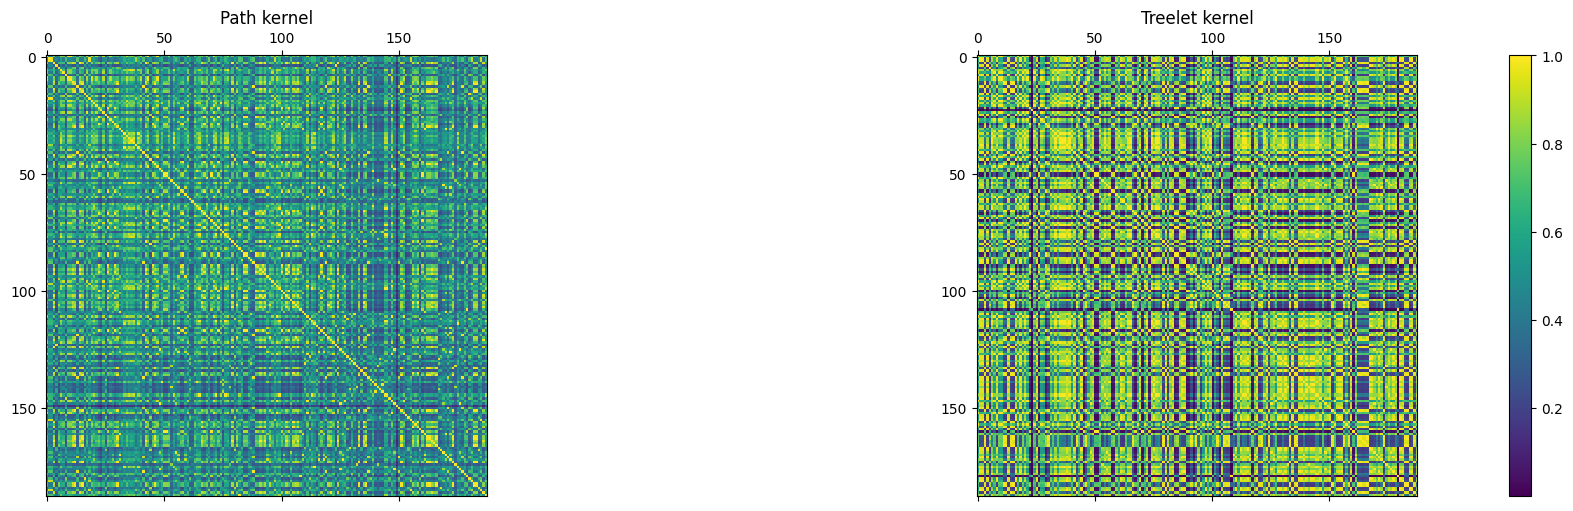

In [ ]:
%matplotlib inline

# Display the gram matrix
mosaic = "AB"
fig = plt.figure(layout="constrained",figsize=(20,5) )
ax_dict = fig.subplot_mosaic(mosaic)

# Compute vmin and vmax for both matrices
vmin = min(np.min(gram_matrix_path), np.min(gram_matrix_treelet))
vmax = max(np.max(gram_matrix_path), np.max(gram_matrix_treelet))

im1 = ax_dict["A"].matshow(gram_matrix_path, vmin=vmin, vmax=vmax)
ax_dict["A"].set_title("Path kernel")

im2 = ax_dict["B"].matshow(gram_matrix_treelet, vmin=vmin, vmax=vmax)
ax_dict["B"].set_title("Treelet kernel")

# Add colorbar
fig.colorbar(im1, ax=[ax_dict["A"], ax_dict["B"]])


-8.770678541212835e-17


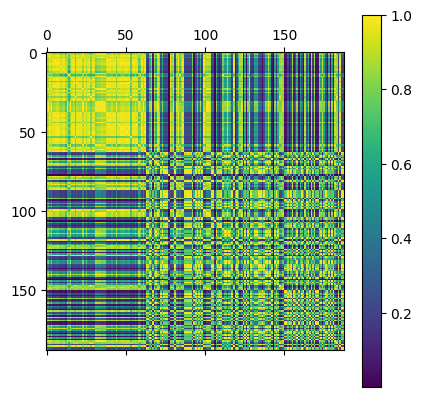

In [41]:
# Visualisation des kernels en fonction de la classe
# Verification que la matrice de Gram est bien definie positive
order = np.argsort(y_MUTAG)
K_range = gram_matrix_treelet[order,:][:,order]
plt.matshow(K_range)
plt.colorbar()
print(np.min(np.linalg.eigvalsh(K_range)))

In [42]:
# y distribution
np.unique(y_MUTAG,return_counts=True)

(array([0, 1]), array([ 63, 125]))

Now, we will compute a SVM-C model to build a predictive model based on this two kernels. 

1) Check the sklearn documentation to understand how to use our kernels
2) What are the hyperparameters to tune ?
3) Compare the two methods. What metric do you use ? 

In [43]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

def train_test_split_gram(gram_matrix, y, test_size=0.1):
    n_samples = gram_matrix.shape[0]
    # Créez un index pour diviser la matrice
    indices = np.arange(n_samples)
    train_indices, test_indices = train_test_split(indices, test_size=test_size)
    gram_matrix_train = gram_matrix[train_indices][:, train_indices]
    gram_matrix_test = gram_matrix[test_indices][:, train_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]
    return gram_matrix_train, gram_matrix_test, y_train, y_test

svc = SVC()
parameters = {'kernel':["precomputed"], #what kernel to use ?
               'C':np.logspace(-2,6,10)
               }
accuracies_path = {"train":[],"val":[],"test":[]}


for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split_gram(gram_matrix_path,y_MUTAG,test_size=0.1)
    clf = GridSearchCV(svc, parameters)
    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    accuracies_path["test"].append(accuracy_score(y_test, y_pred_test))
    accuracies_path["train"].append(accuracy_score(y_train, y_pred_train))
    accuracies_path["val"].append(clf.best_score_)
    
print(f"Mean and std accuracies with Path Kernel : {np.mean(accuracies_path['test']):.2f}, {np.std(accuracies_path['test']):.2f}")


100%|██████████| 10/10 [00:00<00:00, 11.80it/s]

Mean and std accuracies with Path Kernel : 0.88, 0.08


In [ ]:

# Same with Treelet kernels
accuracies_treelet = {"train":[],"val":[],"test":[]}

for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split_gram(gram_matrix_treelet,y_MUTAG,test_size=0.1)
    clf = GridSearchCV(svc, parameters)
    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    accuracies_treelet["test"].append(accuracy_score(y_test, y_pred_test))
    accuracies_treelet["train"].append(accuracy_score(y_train, y_pred_train))
    accuracies_treelet["val"].append(clf.best_score_)

    
print(f"Mean and std accuracies with Treelet Kernel : {np.mean(accuracies_treelet['test']):.2f}, {np.std(accuracies_treelet['test']):.2f}")



100%|██████████| 10/10 [00:00<00:00, 11.77it/s]

Mean and std accuracies with Treelet Kernel : 0.81, 0.06


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

parameters = {'kernel':[], #what kernel to use ?
               'C':np.logspace(-2,6,10)
               }


def train_test_split_gram(gram_matrix, y, test_size=0.1):
    n_samples = gram_matrix.shape[0]
    # Créez un index pour diviser la matrice
    indices = np.arange(n_samples)
    train_indices, test_indices = train_test_split(indices, test_size=test_size)
    gram_matrix_train = gram_matrix[train_indices][:, train_indices]
    gram_matrix_test = gram_matrix[test_indices][:, train_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]
    return gram_matrix_train, gram_matrix_test, y_train, y_test

svc = ...
accuracies_path = {"train":[],"val":[],"test":[]}


for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split_gram(gram_matrix_path,y_MUTAG,test_size=0.1)
    clf = ...

    y_pred_train = ...
    y_pred_test = ...
    accuracies_path["test"].append(accuracy_score(y_test, y_pred_test))
    accuracies_path["train"].append(accuracy_score(y_train, y_pred_train))
    accuracies_path["val"].append(clf.best_score_)
    
print(f"Mean and std accuracies with Path Kernel : {np.mean(accuracies_path['test']):.2f}, {np.std(accuracies_path['test']):.2f}")

# Same with Treelet kernels (pas ouf dans le code, on devrait éviter de répéter le code)
accuracies_treelet = {"train":[],"val":[],"test":[]}

for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split_gram(gram_matrix_treelet,y_MUTAG,test_size=0.1)
    clf = ...
    y_pred_train = ...
    y_pred_test = ...
    accuracies_treelet["test"].append(accuracy_score(y_test, y_pred_test))
    accuracies_treelet["train"].append(accuracy_score(y_train, y_pred_train))
    accuracies_treelet["val"].append(clf.best_score_)

    
print(f"Mean and std accuracies with Treelet Kernel : {np.mean(accuracies_treelet['test']):.2f}, {np.std(accuracies_treelet['test']):.2f}")



In [45]:
from IPython.display import display, HTML
from tabulate import tabulate

def display_table(accuracies_path, accuracies_treelet):
    headers = ["Kernel", "Train", "Val", "Test"]
    table_data = []

    for kernel, accuracies in [("Path Kernel", accuracies_path), ("Treelet Kernel", accuracies_treelet)]:
        train_str = f"{np.mean(accuracies['train']):.2f} ± {np.std(accuracies['train']):.2f}"
        val_str = f"{np.mean(accuracies['val']):.2f} ± {np.std(accuracies['val']):.2f}"
        test_str = f"{np.mean(accuracies['test']):.2f} ± {np.std(accuracies['test']):.2f}"

        table_data.append([kernel, train_str, val_str, test_str])

    display(HTML(tabulate(table_data, headers=headers, tablefmt='html')))

display_table(accuracies_path, accuracies_treelet)




Kernel,Train,Val,Test
Path Kernel,0.95 ± 0.02,0.88 ± 0.01,0.88 ± 0.08
Treelet Kernel,0.91 ± 0.02,0.88 ± 0.01,0.81 ± 0.06


### Acyclic

Here, we will compare our graph kernel methods together, but also with the first results obtained only using an embedding.

1) Complete the code to compute the two graph kernels on the Acyclic dataset
2) Visualize the Gram matrices. What do you think about your gamma parameter choice ? Understand what is happening and try to improve it. 

In [9]:
# Initailize parameters for graph kernel computation.
kernel_options = {'depth': 3,'k_func': 'MinMax','compute_method': 'trie'}
# Initialize graph kernel.
graph_kernel_path = PathUpToH(node_labels=['atom_symbol'], # list of node label names.
						 #ds_infos=dataset.get_dataset_infos(keys=['directed']), # dataset information required for computation.
						 **kernel_options, # options for computation.
						 )

#V1
graph_kernel_treelet = Treelet(node_labels=['atom_symbol'], # list of node label names.)
                       sub_kernel = functools.partial(gaussian_kernel, gamma=0.005) , # Sub-kernel for computing treelet kernel.
                       ds_infos = {'directed': False}, # dataset information required for computation.
								)


# Compute Gram matrix.
gram_matrix_treelet, _ = graph_kernel_treelet.compute(graphs_Acyclic)
gram_matrix_path, _ = graph_kernel_path.compute(graphs_Acyclic)

np.min(np.linalg.eigvalsh(gram_matrix_treelet)) # ! attention à bien utiliser le gklearn modifié



NameError: name 'graphs_Acyclic' is not defined

In [55]:
import pickle

with open('data/gram_matrix_acyclic.pkl', 'wb') as f:
    pickle.dump((gram_matrix_treelet, gram_matrix_path), f)
    

In [2]:
import pickle

with open('data/gram_matrix_acyclic.pkl', 'rb') as f:
    gram_matrix_treelet, gram_matrix_path = pickle.load(f)
    

In [3]:
%matplotlib inline
# Print results.

mosaic = "AB"
fig = plt.figure(layout="constrained",figsize=(20,5) )
ax_dict = fig.subplot_mosaic(mosaic)

# Compute vmin and vmax for both matrices
vmin = min(np.min(gram_matrix_path), np.min(gram_matrix_treelet))
vmax = max(np.max(gram_matrix_path), np.max(gram_matrix_treelet))

im1 = ax_dict["A"].matshow(gram_matrix_path, vmin=vmin, vmax=vmax)
ax_dict["A"].set_title("Path kernel")

im2 = ax_dict["B"].matshow(gram_matrix_treelet, vmin=vmin, vmax=vmax)
ax_dict["B"].set_title("Treelet kernel")

# Add colorbar
fig.colorbar(im1, ax=[ax_dict["A"], ax_dict["B"]])


NameError: name 'plt' is not defined

Now, we will check in details the influence of `C` parameter.

1) Complete the code to split the data into train and test and learn a SVR with default hyperparameters.
2) What is the train and test performances ? What is the default value for `C` ? 

In [ ]:
svr = ...
X_train, X_test, y_train, y_test = ...

y_pred_train = ...
y_pred_test = ...
print(mean_absolute_error(y_train, y_pred_train))    
print(mean_absolute_error(y_test, y_pred_test))    

print(f"C = {...}")


1) Based on your understanding of SVM, how to tune the `C` parameter to reduce the training error ? 
2) Plot the MAE on train set for `C=1,10,100,1000,10000,100000`
3) Do the same with MAE on test set
4) What is the best value for `C` ? Why ?

In [ ]:
C_values = [1,10,100,1000,10000,10000000]

mae_train_C = []
mae_test_C = []

for C in C_values:
    svr = ...
    mae_train_C.append( ...)
    mae_test_C.append(...)  
    

In [59]:
plt.plot(C_values,mae_train_C,label="train")
plt.plot(C_values,mae_test_C,label="test")
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('MAE')
plt.legend()
plt.show()


NameError: name 'C_values' is not defined

In [ ]:
#Comparaison of both kernels

parameters = {'kernel':['precomputed'], 
              'C':np.logspace(-2,6,10),
              'epsilon':np.logspace(-1,1,10)}
methods = [
    {"name": "Treelet Kernel", "K": gram_matrix_treelet},
    {"name": "Path Kernel", "K": gram_matrix_path},
]

splits = []
n=gram_matrix_path.shape[0]
# Créer les divisions et les stocker
for _ in range(10):
    idx_train,idx_test = train_test_split(np.arange(n), test_size=0.1)
    splits.append((idx_train,idx_test))

def evaluate_model_gram(K,y, parameters, splits):
    mae_runs = []
    
    for (idx_train, idx_test) in tqdm(splits):
        K_train = K[idx_train][:,idx_train] 
        K_test = K[idx_test][:,idx_train]
        clf = GridSearchCV(svr, parameters, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error')
        
        clf.fit(K_train, y[idx_train])
        y_pred_test = clf.predict(K_test)
        mae_runs.append(mean_absolute_error(y[idx_test], y_pred_test))
    return np.mean(mae_runs), np.std(mae_runs)

for method in methods:
    mean_mae, std_mae = evaluate_model_gram(method["K"], y_Acyclic, parameters, splits)
    print(f"{method['name']}: Mean MAE = {mean_mae:.2f}, Std MAE = {std_mae:.2f}")

# Resultats bien meilleurs ! 

100%|██████████| 10/10 [00:28<00:00,  2.89s/it]


Treelet Kernel: Mean MAE = 3.97, Std MAE = 0.62


100%|██████████| 10/10 [00:08<00:00,  1.14it/s]

Path Kernel: Mean MAE = 5.39, Std MAE = 1.64


# GNN

For this last part, we will use a GNN to predict the boiling point of the Acyclic dataset.

To this end, we will rely on the pytorch geometric library which provides a lot of tools to handle graph neural networks. 

To install this library, you can run the following command : `!pip install torch_geometric` on a colab notebook. You will also need to install `greycdata`.

Link to the colab version : https://colab.research.google.com/drive/1780QgNOKshIoMcDg01rISmz4CDnLl4F9?usp=sharing

In [ ]:
from tqdm import tqdm 
import torch
from greycdata.datasets import GreycDataset

# Loading the Acyclic dataset
dataset = GreycDataset(name='Acyclic',root='data/Acyclic')

In [4]:

# Save the dataset
torch.save(dataset, 'data/dataset_acyclic.pth')

In [ ]:
# load the dataset
dataset = torch.load('data/dataset_acyclic.pth')


GreycDataset(183)

In [6]:
# Split data
dataset = dataset.shuffle()
ratio_train = .9
size_train = int(len(dataset)*ratio_train)
size_test = len(dataset)-size_train
train_dataset = dataset[:size_train]
test_dataset = dataset[size_train:]

print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

Number of training graphs: 164
Number of test graphs: 19


In [7]:
# Convert data to torch data
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [10]:
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.nn import global_add_pool

# Creation of a basic GCN model. 
class MyGCN(torch.nn.Module):
    def __init__(self, input_channels,hidden_channels):
        super(MyGCN, self).__init__()
        self.conv1 = GCNConv(input_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        # Convolution layers
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        
        # Read out (pooling) layer
        x = global_add_pool(x, batch) 
        x = self.lin(x)
        return x

model = MyGCN(input_channels=dataset.num_features,hidden_channels=64)
print(model)

MyGCN(
  (conv1): GCNConv(15, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=1, bias=True)
)


In [22]:
model = MyGCN(input_channels=dataset.num_features,hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.03) # How we make the gradient descent
criterion = torch.nn.MSELoss(reduction="sum") # How we compute the loss, evaluate the performance of the model on train set

def train(model,loader, optimizer, criterion):
    model.train()
    loss_epoch = 0.0
    for data in loader:  # Iterate in batches over the training dataset.
        optimizer.zero_grad()  # Clear gradients.
        out = model(data.x, data.edge_index, data.batch)  # Perform a single forward pass.
        loss = criterion(out, data.y.reshape(-1,1))  # Compute the loss.
        loss_epoch += loss.item()
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.
        loss_epoch += loss.item()
    return loss_epoch/len(loader.dataset)

def test(model,loader):
    model.eval()
    errors = []
    for data in loader:  # Iterate in batches over the training/test dataset.
        out = model(data.x, data.edge_index, data.batch)  
        errors.extend(out.detach() - data.y.detach().reshape(-1,1))
    # computation of mae
    return np.mean([abs(e.item()) for e in errors])

losses=[]
accuracies_train = []
accuracies_test = []

for epoch in tqdm(range(1, 1000)):
    loss = train(model, train_loader, optimizer, criterion)
    losses.append(loss)
    train_acc = test(model,train_loader).item()
    test_acc = test(model,test_loader).item()
    accuracies_train.append(train_acc)
    accuracies_test.append(test_acc)
    

100%|██████████| 999/999 [01:12<00:00, 13.78it/s]


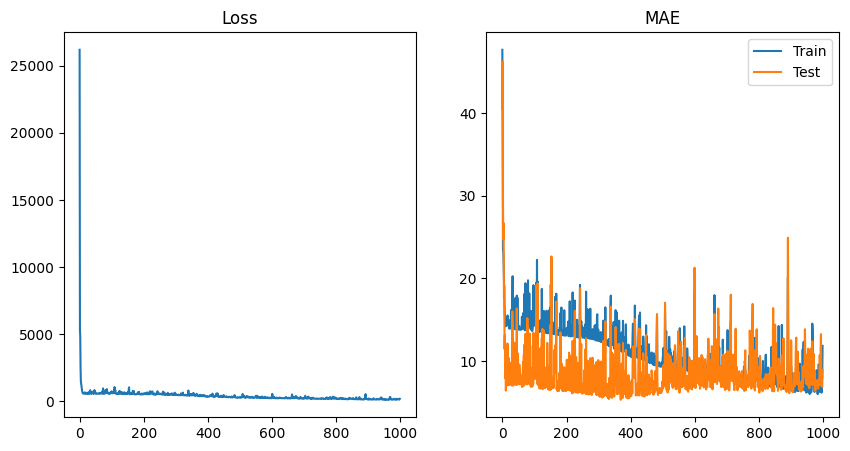

In [24]:
%matplotlib inline 

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(losses)
ax[0].set_title('Loss')
ax[1].plot(accuracies_train, label='Train')
ax[1].plot(accuracies_test, label='Test')
ax[1].set_title('MAE')
ax[1].legend()
plt.show()

In [ ]:
import numpy as np

print(f"Train MSE: {test(model,train_loader)}")
print(f"Test MSE: {test(model, test_loader)}")


Train MSE: 11.853239454874178
Test MSE: 8.933977428235506
5.32824727108604
